__LRG_OPT and LRG_IR as defined in the updated selection__

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest_path = '/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/alltiles_LRGzinfo_mw_trans_added.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS'])
idx = np.where(tmp['TARGETS']=='QSO+LRG')[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

674227
37119


In [4]:
deep = zbest.copy()

# Select deep coadds
mask = deep['subset']=='deep'
print(np.sum(mask))
# # Select QSO+LRG tiles
# mask &= deep['TARGETS']=='QSO+LRG'
# print(np.sum(mask))
deep = deep[mask]

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = deep['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

# # Ting-Wen's quality cuts
# mask = deep['DELTACHI2']>20
# mask &= deep['Z']<1.4
# mask &= deep['ZWARN']==0
# print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# deep = deep[mask]

print(len(deep))
print(len(np.unique(deep['TARGETID'])))

deep_columns_old = ['Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR', 'EFFTIME_DARK', 'EFFTIME_BRIGHT', 'EFFTIME_BACK']
deep_columns_new = ['Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'SUBTYPE_deep', 'DELTACHI2_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep', 'EFFTIME_DARK_deep', 'EFFTIME_BRIGHT_deep', 'EFFTIME_BACK_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

34868
FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 18686 10684 0.636227442969016
18686
18686


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    deep['gmag'] = 22.5 - 2.5*np.log10(deep['FLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rmag'] = 22.5 - 2.5*np.log10(deep['FLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zmag'] = 22.5 - 2.5*np.log10(deep['FLUX_Z']/deep['MW_TRANSMISSION_Z'])
    deep['w1mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W1']/deep['MW_TRANSMISSION_W1'])
    deep['w2mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W2']/deep['MW_TRANSMISSION_W2'])
    deep['gfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']/deep['MW_TRANSMISSION_Z'])

In [6]:
mask = zbest['RZR']=='single_exposures'
zbest = zbest[mask]
print(len(zbest))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
zbest = zbest[mask]
print(len(zbest))

print(len(np.unique(zbest['TARGETID'])))

deep_columns = deep_columns_new+['TARGETID', 'gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'gfibermag', 'rfibermag', 'zfibermag']
zbest = join(zbest, deep[deep_columns], keys='TARGETID')

429668
238615
18686


In [7]:
zbest['EXPID'] = np.array(zbest['subset'], dtype=int)

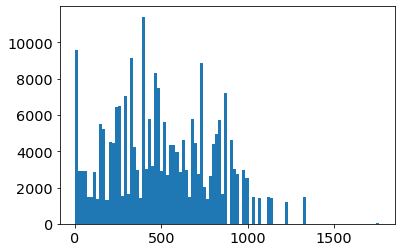

45461 0.19052029419776628


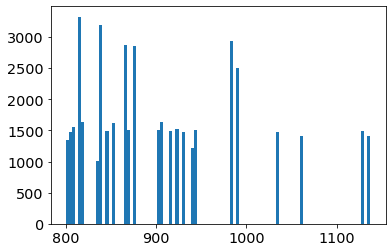

907.5743860022511
876.72216796875


In [8]:
plt.hist(zbest['EFFTIME_DARK'], 100)
plt.show()

mask = (zbest['EFFTIME_DARK'] > 800) & (zbest['EFFTIME_DARK'] < 1200)
print(np.sum(mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

plt.hist(zbest['EFFTIME_DARK'], 100)
plt.show()

print(np.mean(zbest['EFFTIME_DARK']))
print(np.median(zbest['EFFTIME_DARK']))

In [9]:
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

45461
15748


In [11]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [12]:
# Changelog (v1.3):
# - Add GAIA_G>18 cut
# - Revised low-z (g-r vs r-W1) cuts from Jeff (same north and south cuts)
# - Shift the low-z cut intercept by 0.1 in the north (decreasing the density), to account for the north vs south difference
# - Shift the sliding IR cut intercept by 0.05*1.8 (increasing the density), to match the optical target density
# - Replace the low-z middle cut with a horizontal g-r>1.3 cut

# mask_north = cat['PHOTSYS']=='N'
# mask_south = cat['PHOTSYS']=='S'

#################### Updated optical selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_north = lrg_mask.copy()

lrg_opt = lrg_opt_south | lrg_opt_north
print(np.sum(lrg_opt))

#################### Updated IR selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_north = lrg_mask.copy()

lrg_ir = lrg_ir_south | lrg_ir_north
print(np.sum(lrg_ir))

12145
12748


In [13]:
# lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
# lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = zbest['SV1_DESI_TARGET'] & 2**0>0
lrg_sv_opt = zbest['SV1_DESI_TARGET'] & 2**5>0
lrg_sv_ir = zbest['SV1_DESI_TARGET'] & 2**6>0
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print(np.sum(lrg_sv_opt))
print(np.sum(lrg_sv_ir))

12145
12748
45461
33612
39338


In [14]:
print('Total # exposures in this analysis:', len(np.unique(zbest['EXPID'])))
t = Table()
t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
t['n_exp'] = 0
for index, tileid in enumerate(t['TILEID']):
    mask = zbest['TILEID']==tileid
    t['n_exp'][index] = len(np.unique(zbest['EXPID'][mask]))
t

Total # exposures in this analysis: 32


TILEID,count,n_exp
int64,int64,int64
80605,6153,4
80607,8740,6
80609,8181,5
80620,4086,3
80622,3673,3
80678,1348,1
80680,4435,3
80688,3005,2
80690,1316,1


--------

In [15]:
mask_zwarn = (zbest['ZWARN_deep']==0)

# Not repeatable
zdiff_threshold = 0.0033
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > zdiff_threshold
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))
# Also include objects with ZWARN!=0 in the deep coadds
mask_fail |= (~mask_zwarn)
print(np.sum(mask_fail), np.sum(mask_fail)/len(mask_fail))

4242 0.09331074987351796
4295 0.09447658432502584


In [16]:
print('Overall failure rates:')
print('LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(lrg_opt & mask_fail)/np.sum(lrg_opt)*100, np.sum(lrg_opt & mask_fail), np.sum(lrg_opt)))
print('LRG_IR:  {:.1f}% ({}/{})'.format(np.sum(lrg_ir & mask_fail)/np.sum(lrg_ir)*100, np.sum(lrg_ir & mask_fail), np.sum(lrg_ir)))
print('LRG_SV:  {:.1f}% ({}/{})'.format(np.sum(lrg_sv & mask_fail)/np.sum(lrg_sv)*100, np.sum(lrg_sv & mask_fail), np.sum(lrg_sv)))

Overall failure rates:
LRG_OPT: 1.6% (193/12145)
LRG_IR:  2.6% (331/12748)
LRG_SV:  9.4% (4295/45461)


In [17]:
# ZWARN cut on single exposures
mask_quality = zbest['ZWARN']==0

print('Fraction removed:')
print('LRG_OPT: {:.1f}%'.format(np.sum((~mask_quality) & lrg_opt)/np.sum(lrg_opt)*100))
print('LRG_IR:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_ir)/np.sum(lrg_ir)*100))
print('LRG_SV:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv)/np.sum(lrg_sv)*100))
print()

print('Overall failure rates:')
print('LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_opt & mask_fail)/np.sum(mask_quality & lrg_opt)*100, np.sum(mask_quality & lrg_opt & mask_fail), np.sum(mask_quality & lrg_opt)))
print('LRG_IR:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_ir & mask_fail)/np.sum(mask_quality & lrg_ir)*100, np.sum(mask_quality & lrg_ir & mask_fail), np.sum(mask_quality & lrg_ir)))
print('LRG_SV:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv & mask_fail)/np.sum(mask_quality & lrg_sv)*100, np.sum(mask_quality & lrg_sv & mask_fail), np.sum(mask_quality & lrg_sv)))

Fraction removed:
LRG_OPT: 1.0%
LRG_IR:  1.9%
LRG_SV:  10.5%

Overall failure rates:
LRG_OPT: 0.9% (111/12018)
LRG_IR:  1.4% (169/12505)
LRG_SV:  3.3% (1354/40682)


In [18]:
# ZWARN and redshift cuts on single exposures
mask_quality = zbest['ZWARN']==0
mask_quality &= zbest['Z']<1.4

print('Fraction removed:')
print('LRG_OPT: {:.1f}%'.format(np.sum((~mask_quality) & lrg_opt)/np.sum(lrg_opt)*100))
print('LRG_IR:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_ir)/np.sum(lrg_ir)*100))
print('LRG_SV:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv)/np.sum(lrg_sv)*100))
print()

print('Overall failure rates:')
print('LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_opt & mask_fail)/np.sum(mask_quality & lrg_opt)*100, np.sum(mask_quality & lrg_opt & mask_fail), np.sum(mask_quality & lrg_opt)))
print('LRG_IR:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_ir & mask_fail)/np.sum(mask_quality & lrg_ir)*100, np.sum(mask_quality & lrg_ir & mask_fail), np.sum(mask_quality & lrg_ir)))
print('LRG_SV:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv & mask_fail)/np.sum(mask_quality & lrg_sv)*100, np.sum(mask_quality & lrg_sv & mask_fail), np.sum(mask_quality & lrg_sv)))

Fraction removed:
LRG_OPT: 1.3%
LRG_IR:  2.4%
LRG_SV:  11.6%

Overall failure rates:
LRG_OPT: 0.7% (81/11984)
LRG_IR:  1.0% (128/12442)
LRG_SV:  2.6% (1027/40191)


In [19]:
# ZWARN, redshift, and DELTACHI2 cuts on single exposures

# Ting-Wen's quality cuts
mask_quality = zbest['DELTACHI2']>20
mask_quality &= zbest['Z']<1.4
mask_quality &= zbest['ZWARN']==0

print('Fraction removed:')
print('LRG_OPT: {:.1f}%'.format(np.sum((~mask_quality) & lrg_opt)/np.sum(lrg_opt)*100))
print('LRG_IR:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_ir)/np.sum(lrg_ir)*100))
print('LRG_SV:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv)/np.sum(lrg_sv)*100))
print()

print('Overall failure rates:')
print('LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_opt & mask_fail)/np.sum(mask_quality & lrg_opt)*100, np.sum(mask_quality & lrg_opt & mask_fail), np.sum(mask_quality & lrg_opt)))
print('LRG_IR:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_ir & mask_fail)/np.sum(mask_quality & lrg_ir)*100, np.sum(mask_quality & lrg_ir & mask_fail), np.sum(mask_quality & lrg_ir)))
print('LRG_SV:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv & mask_fail)/np.sum(mask_quality & lrg_sv)*100, np.sum(mask_quality & lrg_sv & mask_fail), np.sum(mask_quality & lrg_sv)))

Fraction removed:
LRG_OPT: 2.4%
LRG_IR:  3.8%
LRG_SV:  19.0%

Overall failure rates:
LRG_OPT: 0.4% (49/11853)
LRG_IR:  0.6% (75/12260)
LRG_SV:  1.0% (378/36815)


In [26]:
# ZWARN, redshift, and DELTACHI2 cuts on single exposures
# and quality cuts on deep coadds

# Ting-Wen's quality cuts
mask_quality = zbest['DELTACHI2']>20
mask_quality &= zbest['Z']<1.4
mask_quality &= zbest['ZWARN']==0

# Ting-Wen's quality cuts
mask = zbest['DELTACHI2_deep']>20
mask &= zbest['Z_deep']<1.4
mask &= zbest['ZWARN_deep']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask_quality &= np.in1d(zbest['TARGETID'], zbest['TARGETID'][mask])


print('Fraction removed:')
print('LRG_OPT: {:.1f}%'.format(np.sum((~mask_quality) & lrg_opt)/np.sum(lrg_opt)*100))
print('LRG_IR:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_ir)/np.sum(lrg_ir)*100))
print('LRG_SV:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv)/np.sum(lrg_sv)*100))
print()

print('Overall failure rates:')
print('LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_opt & mask_fail)/np.sum(mask_quality & lrg_opt)*100, np.sum(mask_quality & lrg_opt & mask_fail), np.sum(mask_quality & lrg_opt)))
print('LRG_IR:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_ir & mask_fail)/np.sum(mask_quality & lrg_ir)*100, np.sum(mask_quality & lrg_ir & mask_fail), np.sum(mask_quality & lrg_ir)))
print('LRG_SV:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv & mask_fail)/np.sum(mask_quality & lrg_sv)*100, np.sum(mask_quality & lrg_sv & mask_fail), np.sum(mask_quality & lrg_sv)))

Quality cuts 44380 1081 0.9762213765645278
Fraction removed:
LRG_OPT: 2.5%
LRG_IR:  4.0%
LRG_SV:  19.2%

Overall failure rates:
LRG_OPT: 0.4% (43/11846)
LRG_IR:  0.5% (59/12243)
LRG_SV:  0.8% (294/36723)


In [27]:
# Quality cut on deep coadds

# Ting-Wen's quality cuts
mask = zbest['DELTACHI2_deep']>20
mask &= zbest['Z_deep']<1.4
mask &= zbest['ZWARN_deep']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask_quality = np.in1d(zbest['TARGETID'], zbest['TARGETID'][mask])

print('Fraction removed:')
print('LRG_OPT: {:.1f}%'.format(np.sum((~mask_quality) & lrg_opt)/np.sum(lrg_opt)*100))
print('LRG_IR:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_ir)/np.sum(lrg_ir)*100))
print('LRG_SV:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv)/np.sum(lrg_sv)*100))
print()

print('Overall failure rates:')
print('LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_opt & mask_fail)/np.sum(mask_quality & lrg_opt)*100, np.sum(mask_quality & lrg_opt & mask_fail), np.sum(mask_quality & lrg_opt)))
print('LRG_IR:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_ir & mask_fail)/np.sum(mask_quality & lrg_ir)*100, np.sum(mask_quality & lrg_ir & mask_fail), np.sum(mask_quality & lrg_ir)))
print('LRG_SV:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv & mask_fail)/np.sum(mask_quality & lrg_sv)*100, np.sum(mask_quality & lrg_sv & mask_fail), np.sum(mask_quality & lrg_sv)))

Quality cuts 44380 1081 0.9762213765645278
Fraction removed:
LRG_OPT: 0.4%
LRG_IR:  0.9%
LRG_SV:  2.4%

Overall failure rates:
LRG_OPT: 1.2% (150/12095)
LRG_IR:  2.0% (249/12635)
LRG_SV:  7.8% (3467/44380)


In [22]:
# MEDIUM and WISE masks
maskbits = [8, 11]
mask_quality = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_quality &= (zbest['MASKBITS'] & 2**bit)==0

print('Fraction removed:')
print('LRG_OPT: {:.1f}%'.format(np.sum((~mask_quality) & lrg_opt)/np.sum(lrg_opt)*100))
print('LRG_IR:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_ir)/np.sum(lrg_ir)*100))
print('LRG_SV:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv)/np.sum(lrg_sv)*100))
print()

print('Overall failure rates:')
print('LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_opt & mask_fail)/np.sum(mask_quality & lrg_opt)*100, np.sum(mask_quality & lrg_opt & mask_fail), np.sum(mask_quality & lrg_opt)))
print('LRG_IR:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_ir & mask_fail)/np.sum(mask_quality & lrg_ir)*100, np.sum(mask_quality & lrg_ir & mask_fail), np.sum(mask_quality & lrg_ir)))
print('LRG_SV:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv & mask_fail)/np.sum(mask_quality & lrg_sv)*100, np.sum(mask_quality & lrg_sv & mask_fail), np.sum(mask_quality & lrg_sv)))

Fraction removed:
LRG_OPT: 6.4%
LRG_IR:  7.3%
LRG_SV:  7.0%

Overall failure rates:
LRG_OPT: 1.6% (178/11373)
LRG_IR:  2.5% (301/11818)
LRG_SV:  9.3% (3940/42294)


In [25]:
# ZWARN, redshift, and DELTACHI2 cuts on single exposures
# and quality cuts on deep coadds
# and MEDIUM and WISE masks

# Ting-Wen's quality cuts
mask_quality = zbest['DELTACHI2']>20
mask_quality &= zbest['Z']<1.4
mask_quality &= zbest['ZWARN']==0

maskbits = [8, 11]
# mask_quality = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_quality &= (zbest['MASKBITS'] & 2**bit)==0

# Ting-Wen's quality cuts
mask = zbest['DELTACHI2_deep']>20
mask &= zbest['Z_deep']<1.4
mask &= zbest['ZWARN_deep']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask_quality &= np.in1d(zbest['TARGETID'], zbest['TARGETID'][mask])


print('Fraction removed:')
print('LRG_OPT: {:.1f}%'.format(np.sum((~mask_quality) & lrg_opt)/np.sum(lrg_opt)*100))
print('LRG_IR:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_ir)/np.sum(lrg_ir)*100))
print('LRG_SV:  {:.1f}%'.format(np.sum((~mask_quality) & lrg_sv)/np.sum(lrg_sv)*100))
print()

print('Overall failure rates:')
print('LRG_OPT: {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_opt & mask_fail)/np.sum(mask_quality & lrg_opt)*100, np.sum(mask_quality & lrg_opt & mask_fail), np.sum(mask_quality & lrg_opt)))
print('LRG_IR:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_ir & mask_fail)/np.sum(mask_quality & lrg_ir)*100, np.sum(mask_quality & lrg_ir & mask_fail), np.sum(mask_quality & lrg_ir)))
print('LRG_SV:  {:.1f}% ({}/{})'.format(np.sum(mask_quality & lrg_sv & mask_fail)/np.sum(mask_quality & lrg_sv)*100, np.sum(mask_quality & lrg_sv & mask_fail), np.sum(mask_quality & lrg_sv)))

Quality cuts 44380 1081 0.9762213765645278
Fraction removed:
LRG_OPT: 8.7%
LRG_IR:  11.0%
LRG_SV:  24.9%

Overall failure rates:
LRG_OPT: 0.3% (36/11091)
LRG_IR:  0.4% (50/11352)
LRG_SV:  0.8% (276/34146)


------

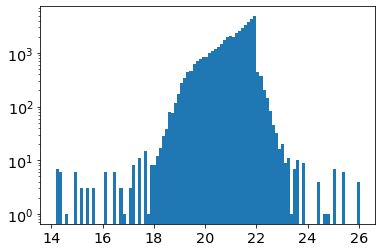

In [28]:
plt.hist(zbest['zfibermag'], 100, log=True);

In [29]:
bins = np.linspace(17.5, 23.2, 58)
print(bins)

[17.5 17.6 17.7 17.8 17.9 18.  18.1 18.2 18.3 18.4 18.5 18.6 18.7 18.8
 18.9 19.  19.1 19.2 19.3 19.4 19.5 19.6 19.7 19.8 19.9 20.  20.1 20.2
 20.3 20.4 20.5 20.6 20.7 20.8 20.9 21.  21.1 21.2 21.3 21.4 21.5 21.6
 21.7 21.8 21.9 22.  22.1 22.2 22.3 22.4 22.5 22.6 22.7 22.8 22.9 23.
 23.1 23.2]


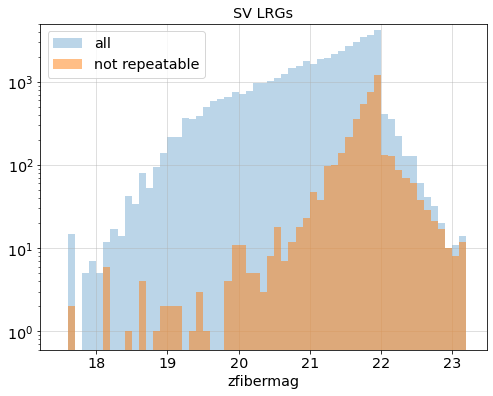

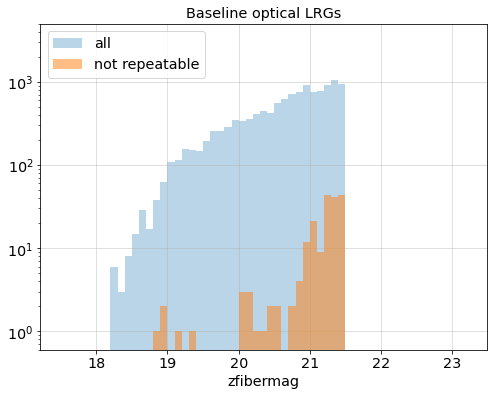

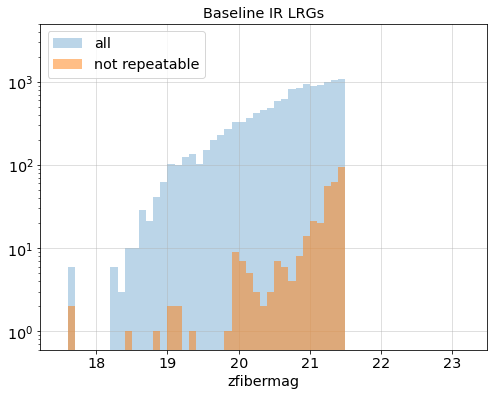

In [33]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['zfibermag'][lrg_sv], bins=bins, alpha=0.3, label='all', zorder=1, log=True)
plt.hist(zbest['zfibermag'][mask_fail & lrg_sv], bins=bins, alpha=0.5, label='not repeatable', zorder=2)
plt.xlabel('zfibermag')
plt.title('SV LRGs')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.ylim(0.6, 5e3)
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(zbest['zfibermag'][lrg_opt], bins=bins, alpha=0.3, label='all', zorder=1, log=True)
plt.hist(zbest['zfibermag'][mask_fail & lrg_opt], bins=bins, alpha=0.5, label='not repeatable', zorder=2)
plt.xlabel('zfibermag')
plt.title('Baseline optical LRGs')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.ylim(0.6, 5e3)
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(zbest['zfibermag'][lrg_ir], bins=bins, alpha=0.3, label='all', zorder=1, log=True)
plt.hist(zbest['zfibermag'][mask_fail & lrg_ir], bins=bins, alpha=0.5, label='not repeatable', zorder=2)
plt.xlabel('zfibermag')
plt.title('Baseline IR LRGs')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.ylim(0.6, 5e3)
plt.show()

<ipython-input-34-2fcb7adb21c8>:5: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv = n_lrg_sv, n_lrg_sv_fail/n_lrg_sv
<ipython-input-34-2fcb7adb21c8>:6: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv, 1/n)  # error floor
<ipython-input-34-2fcb7adb21c8>:11: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_opt = n_lrg_opt, n_lrg_opt_fail/n_lrg_opt
<ipython-input-34-2fcb7adb21c8>:12: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_opt, 1/n)  # error floor
<ipython-input-34-2fcb7adb21c8>:17: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_ir = n_lrg_ir, n_lrg_ir_fail/n_lrg_ir
<ipython-input-34-2fcb7adb21c8>:18: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_ir, 1/n)  # error floor


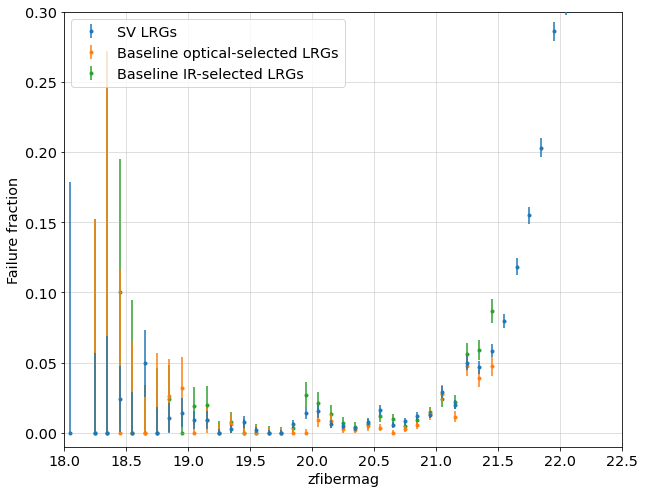

In [34]:
bin_centers = (bins[1:]+bins[:-1])/2

n_lrg_sv, _ = np.histogram(zbest['zfibermag'][lrg_sv], bins=bins)
n_lrg_sv_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv & mask_fail], bins=bins)
n, p_lrg_sv = n_lrg_sv, n_lrg_sv_fail/n_lrg_sv
p1 = np.maximum(p_lrg_sv, 1/n)  # error floor
errors_sv = np.clip(np.sqrt(n * p_lrg_sv * (1-p_lrg_sv))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_opt, _ = np.histogram(zbest['zfibermag'][lrg_opt], bins=bins)
n_lrg_opt_fail, _ = np.histogram(zbest['zfibermag'][lrg_opt & mask_fail], bins=bins)
n, p_lrg_opt = n_lrg_opt, n_lrg_opt_fail/n_lrg_opt
p1 = np.maximum(p_lrg_opt, 1/n)  # error floor
errors_opt = np.clip(np.sqrt(n * p_lrg_opt * (1-p_lrg_opt))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_ir, _ = np.histogram(zbest['zfibermag'][lrg_ir], bins=bins)
n_lrg_ir_fail, _ = np.histogram(zbest['zfibermag'][lrg_ir & mask_fail], bins=bins)
n, p_lrg_ir = n_lrg_ir, n_lrg_ir_fail/n_lrg_ir
p1 = np.maximum(p_lrg_ir, 1/n)  # error floor
errors_ir = np.clip(np.sqrt(n * p_lrg_ir * (1-p_lrg_ir))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

plt.figure(figsize=(10, 8))
plt.errorbar(bin_centers, p_lrg_sv, yerr=(np.clip(errors_sv, None, p_lrg_sv), errors_sv),
             fmt='.', label='SV LRGs', zorder=3)
plt.errorbar(bin_centers, p_lrg_opt, yerr=(np.clip(errors_opt, None, p_lrg_opt), errors_opt),
             fmt='.', label='Baseline optical-selected LRGs', zorder=2)
plt.errorbar(bin_centers, p_lrg_ir, yerr=(np.clip(errors_ir, None, p_lrg_ir), errors_ir),
             fmt='.', label='Baseline IR-selected LRGs', zorder=1)
plt.xlabel('zfibermag')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.xlim(18, 22.5)
plt.ylim(-0.01, 0.3)
plt.legend(loc='upper left')
plt.show()

<ipython-input-35-3714700fba33>:5: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv = n_lrg_sv, n_lrg_sv_fail/n_lrg_sv
<ipython-input-35-3714700fba33>:6: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv, 1/n)  # error floor
<ipython-input-35-3714700fba33>:11: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv_opt = n_lrg_sv_opt, n_lrg_sv_opt_fail/n_lrg_sv_opt
<ipython-input-35-3714700fba33>:12: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv_opt, 1/n)  # error floor
<ipython-input-35-3714700fba33>:17: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv_ir = n_lrg_sv_ir, n_lrg_sv_ir_fail/n_lrg_sv_ir
<ipython-input-35-3714700fba33>:18: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv_ir, 1/n)  # error floor


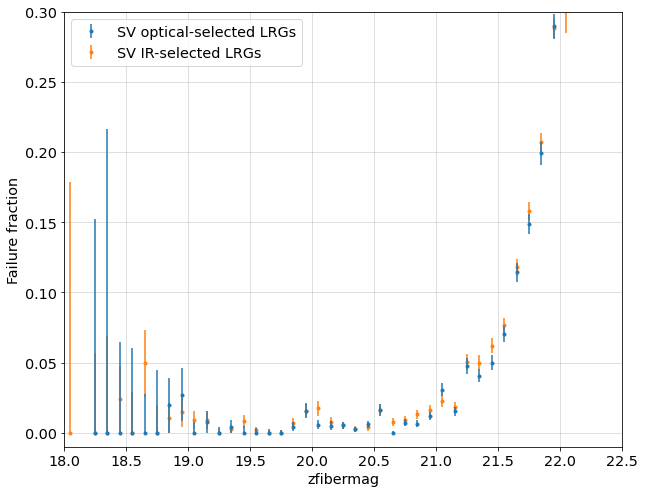

In [35]:
bin_centers = (bins[1:]+bins[:-1])/2

n_lrg_sv, _ = np.histogram(zbest['zfibermag'][lrg_sv], bins=bins)
n_lrg_sv_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv & mask_fail], bins=bins)
n, p_lrg_sv = n_lrg_sv, n_lrg_sv_fail/n_lrg_sv
p1 = np.maximum(p_lrg_sv, 1/n)  # error floor
errors_sv = np.clip(np.sqrt(n * p_lrg_sv * (1-p_lrg_sv))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_sv_opt, _ = np.histogram(zbest['zfibermag'][lrg_sv_opt], bins=bins)
n_lrg_sv_opt_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv_opt & mask_fail], bins=bins)
n, p_lrg_sv_opt = n_lrg_sv_opt, n_lrg_sv_opt_fail/n_lrg_sv_opt
p1 = np.maximum(p_lrg_sv_opt, 1/n)  # error floor
errors_opt = np.clip(np.sqrt(n * p_lrg_sv_opt * (1-p_lrg_sv_opt))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_sv_ir, _ = np.histogram(zbest['zfibermag'][lrg_sv_ir], bins=bins)
n_lrg_sv_ir_fail, _ = np.histogram(zbest['zfibermag'][lrg_sv_ir & mask_fail], bins=bins)
n, p_lrg_sv_ir = n_lrg_sv_ir, n_lrg_sv_ir_fail/n_lrg_sv_ir
p1 = np.maximum(p_lrg_sv_ir, 1/n)  # error floor
errors_ir = np.clip(np.sqrt(n * p_lrg_sv_ir * (1-p_lrg_sv_ir))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

plt.figure(figsize=(10, 8))
# plt.errorbar(bin_centers, p_lrg_sv, yerr=(np.clip(errors_sv, None, p_lrg_sv), errors_sv),
#              fmt='.', label='SV LRGs', zorder=3)
plt.errorbar(bin_centers, p_lrg_sv_opt, yerr=(np.clip(errors_opt, None, p_lrg_sv_opt), errors_opt),
             fmt='.', label='SV optical-selected LRGs', zorder=2)
plt.errorbar(bin_centers, p_lrg_sv_ir, yerr=(np.clip(errors_ir, None, p_lrg_sv_ir), errors_ir),
             fmt='.', label='SV IR-selected LRGs', zorder=1)
plt.xlabel('zfibermag')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.xlim(18, 22.5)
plt.ylim(-0.01, 0.3)
plt.legend(loc='upper left')
plt.show()

<ipython-input-36-aed8d88d2383>:5: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_sv = n_lrg_sv, n_lrg_sv_fail/n_lrg_sv
<ipython-input-36-aed8d88d2383>:6: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_sv, 1/n)  # error floor
<ipython-input-36-aed8d88d2383>:11: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_opt = n_lrg_opt, n_lrg_opt_fail/n_lrg_opt
<ipython-input-36-aed8d88d2383>:12: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_opt, 1/n)  # error floor
<ipython-input-36-aed8d88d2383>:17: RuntimeWarning: invalid value encountered in true_divide
  n, p_lrg_ir = n_lrg_ir, n_lrg_ir_fail/n_lrg_ir
<ipython-input-36-aed8d88d2383>:18: RuntimeWarning: divide by zero encountered in true_divide
  p1 = np.maximum(p_lrg_ir, 1/n)  # error floor


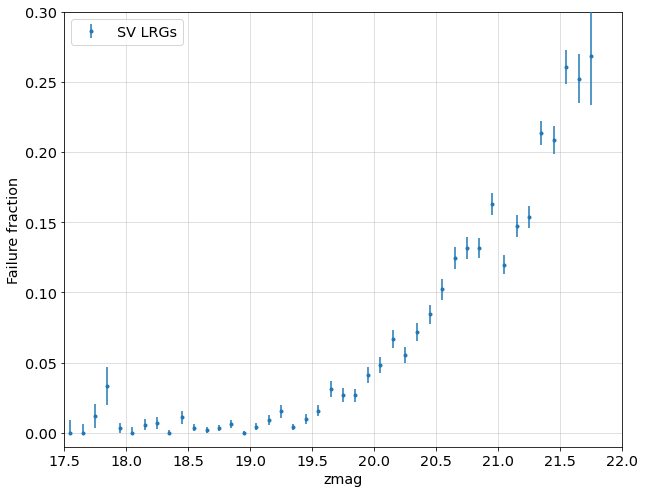

In [36]:
bin_centers = (bins[1:]+bins[:-1])/2

n_lrg_sv, _ = np.histogram(zbest['zmag'][lrg_sv], bins=bins)
n_lrg_sv_fail, _ = np.histogram(zbest['zmag'][lrg_sv & mask_fail], bins=bins)
n, p_lrg_sv = n_lrg_sv, n_lrg_sv_fail/n_lrg_sv
p1 = np.maximum(p_lrg_sv, 1/n)  # error floor
errors_sv = np.clip(np.sqrt(n * p_lrg_sv * (1-p_lrg_sv))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_opt, _ = np.histogram(zbest['zmag'][lrg_opt], bins=bins)
n_lrg_opt_fail, _ = np.histogram(zbest['zmag'][lrg_opt & mask_fail], bins=bins)
n, p_lrg_opt = n_lrg_opt, n_lrg_opt_fail/n_lrg_opt
p1 = np.maximum(p_lrg_opt, 1/n)  # error floor
errors_opt = np.clip(np.sqrt(n * p_lrg_opt * (1-p_lrg_opt))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

n_lrg_ir, _ = np.histogram(zbest['zmag'][lrg_ir], bins=bins)
n_lrg_ir_fail, _ = np.histogram(zbest['zmag'][lrg_ir & mask_fail], bins=bins)
n, p_lrg_ir = n_lrg_ir, n_lrg_ir_fail/n_lrg_ir
p1 = np.maximum(p_lrg_ir, 1/n)  # error floor
errors_ir = np.clip(np.sqrt(n * p_lrg_ir * (1-p_lrg_ir))/n, np.sqrt(n * p1 * (1-p1))/n, 1)

plt.figure(figsize=(10, 8))
plt.errorbar(bin_centers, p_lrg_sv, yerr=(np.clip(errors_sv, None, p_lrg_sv), errors_sv),
             fmt='.', label='SV LRGs', zorder=3)
# plt.errorbar(bin_centers, p_lrg_opt, yerr=(np.clip(errors_opt, None, p_lrg_opt), errors_opt),
#              fmt='.', label='Baseline optical-selected LRGs', zorder=2)
# plt.errorbar(bin_centers, p_lrg_ir, yerr=(np.clip(errors_ir, None, p_lrg_ir), errors_ir),
#              fmt='.', label='Baseline IR-selected LRGs', zorder=1)
plt.xlabel('zmag')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.xlim(17.5, 22)
plt.ylim(-0.01, 0.3)
plt.legend(loc='upper left')
plt.show()

--------

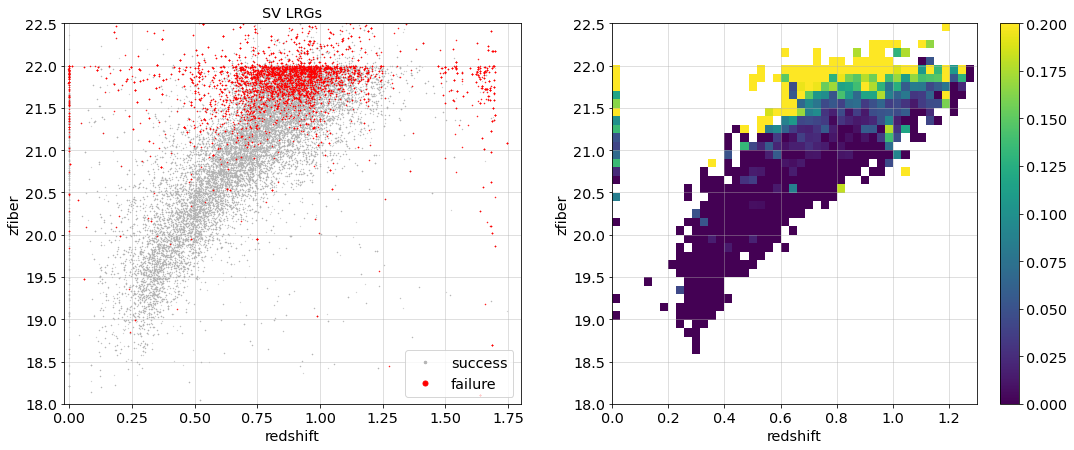

In [37]:
# 2-D failure rates
zfiber_bins = np.linspace(18.5, 22.5, 41)
z_bins = np.linspace(-0.001, 1.4, 50)
# print(zfiber_bins)
# print(z_bins)
hist_all, _, _ = np.histogram2d(zbest['zfibermag'][lrg_sv & mask_zwarn], zbest['Z_deep'][lrg_sv & mask_zwarn], bins=[zfiber_bins, z_bins])
hist_fail, _, _ = np.histogram2d(zbest['zfibermag'][lrg_sv & mask_fail], zbest['Z_deep'][lrg_sv & mask_fail], bins=[zfiber_bins, z_bins])
mask = hist_all<15
hist_fail[mask] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax = axes[0]
ax.plot(zbest['Z_deep'][mask_zwarn & lrg_sv & (~mask_fail)], zbest['zfibermag'][mask_zwarn & lrg_sv & (~mask_fail)], '.', ms=0.5, color='0.7', label='success')
ax.plot(zbest['Z_deep'][mask_fail & lrg_sv], zbest['zfibermag'][mask_fail & lrg_sv], '.', ms=1, color='r', label='failure')
ax.axis([-0.02, 1.8, 18, 22.5])
ax.set_xlabel('redshift')
ax.set_ylabel('zfiber')
ax.grid(alpha=0.5)
ax.legend(loc='lower right')
ax.legend(loc='lower right', markerscale=10)
ax.set_title('SV LRGs')

ax = axes[1]
im = ax.imshow(hist_fail/hist_all, aspect='auto', extent=(z_bins.min(), z_bins.max(), zfiber_bins.min(), zfiber_bins.max()), origin='lower', vmax=0.2)
fig.colorbar(im)
# plt.colorbar()
ax.set_xlabel('redshift')
ax.set_ylabel('zfiber')
ax.grid(alpha=0.5)
ax.axis([0, 1.3, 18, 22.5])
plt.show()

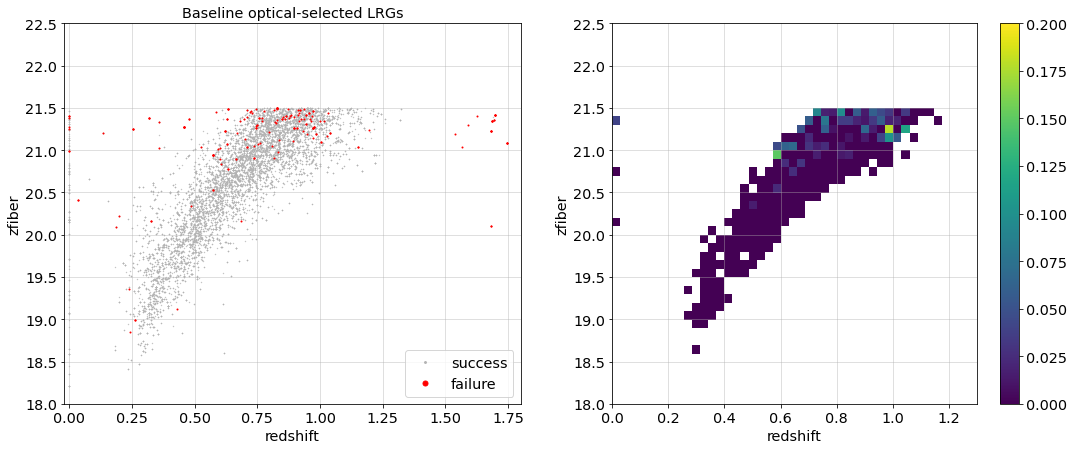

In [38]:
# 2-D failure rates
zfiber_bins = np.linspace(18.5, 22.5, 41)
z_bins = np.linspace(-0.001, 1.4, 50)
# print(zfiber_bins)
# print(z_bins)
hist_all, _, _ = np.histogram2d(zbest['zfibermag'][lrg_opt & mask_zwarn], zbest['Z_deep'][lrg_opt & mask_zwarn], bins=[zfiber_bins, z_bins])
hist_fail, _, _ = np.histogram2d(zbest['zfibermag'][lrg_opt & mask_fail], zbest['Z_deep'][lrg_opt & mask_fail], bins=[zfiber_bins, z_bins])
mask = hist_all<15
hist_fail[mask] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax = axes[0]
ax.plot(zbest['Z_deep'][mask_zwarn & lrg_opt & (~mask_fail)], zbest['zfibermag'][mask_zwarn & lrg_opt & (~mask_fail)], '.', ms=0.75, color='0.7', label='success')
ax.plot(zbest['Z_deep'][mask_fail & lrg_opt], zbest['zfibermag'][mask_fail & lrg_opt], '.', ms=2, color='r', label='failure')
ax.axis([-0.02, 1.8, 18, 22.5])
ax.set_xlabel('redshift')
ax.set_ylabel('zfiber')
ax.grid(alpha=0.5)
ax.legend(loc='lower right')
ax.legend(loc='lower right', markerscale=5)
ax.set_title('Baseline optical-selected LRGs')

ax = axes[1]
im = ax.imshow(hist_fail/hist_all, aspect='auto', extent=(z_bins.min(), z_bins.max(), zfiber_bins.min(), zfiber_bins.max()), origin='lower', vmax=0.2)
fig.colorbar(im)
# plt.colorbar()
ax.set_xlabel('redshift')
ax.set_ylabel('zfiber')
ax.grid(alpha=0.5)
ax.axis([0, 1.3, 18, 22.5])
plt.show()

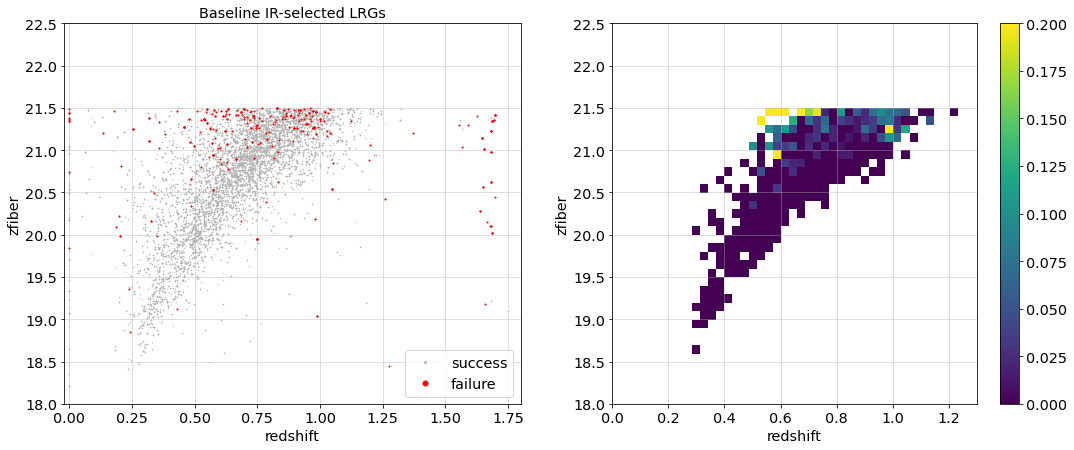

In [39]:
# 2-D failure rates
zfiber_bins = np.linspace(18.5, 22.5, 41)
z_bins = np.linspace(-0.001, 1.4, 50)
# print(zfiber_bins)
# print(z_bins)
hist_all, _, _ = np.histogram2d(zbest['zfibermag'][lrg_ir & mask_zwarn], zbest['Z_deep'][lrg_ir & mask_zwarn], bins=[zfiber_bins, z_bins])
hist_fail, _, _ = np.histogram2d(zbest['zfibermag'][lrg_ir & mask_fail], zbest['Z_deep'][lrg_ir & mask_fail], bins=[zfiber_bins, z_bins])
mask = hist_all<15
hist_fail[mask] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ax = axes[0]
ax.plot(zbest['Z_deep'][mask_zwarn & lrg_ir & (~mask_fail)], zbest['zfibermag'][mask_zwarn & lrg_ir & (~mask_fail)], '.', ms=0.75, color='0.7', label='success')
ax.plot(zbest['Z_deep'][mask_fail & lrg_ir], zbest['zfibermag'][mask_fail & lrg_ir], '.', ms=2, color='r', label='failure')
ax.axis([-0.02, 1.8, 18, 22.5])
ax.set_xlabel('redshift')
ax.set_ylabel('zfiber')
ax.grid(alpha=0.5)
ax.legend(loc='lower right')
ax.legend(loc='lower right', markerscale=5)
ax.set_title('Baseline IR-selected LRGs')

ax = axes[1]
im = ax.imshow(hist_fail/hist_all, aspect='auto', extent=(z_bins.min(), z_bins.max(), zfiber_bins.min(), zfiber_bins.max()), origin='lower', vmax=0.2)
fig.colorbar(im)
# plt.colorbar()
ax.set_xlabel('redshift')
ax.set_ylabel('zfiber')
ax.grid(alpha=0.5)
ax.axis([0, 1.3, 18, 22.5])
plt.show()

-----

In [40]:
def color_plot_3x2_simple(cat, color_col, idx=None, title=None, vmin=0.2, vmax=1.0, cmap='Dark2_r', ms=0.3, show=True, figaxis=None, colorbar=True, figsize=(18, 20), grid=False):
    '''
    Replace the g-r vs r-z panel with g-r vs r-W1
    '''
    if idx is None:
        idx = np.arange(len(cat))

    if figaxis is None:
        fig, axes = plt.subplots(3, 2, figsize=figsize)
    else:
        fig, axes = figaxis

    # non-stellar cut
    im = axes[0, 0].scatter((cat['rmag']-cat['zmag'])[idx], (cat['zmag']-cat['w1mag'])[idx], 
                c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 0].set_xlabel('r - z')
    axes[0, 0].set_ylabel('z - W1')
    axes[0, 0].axis([0.2, 2.8, -1, 3])
    if colorbar:
        fig.colorbar(im, ax=axes[0, 0])
    if grid:
        axes[0, 0].grid(alpha=0.5)

    # g-r vs r-W1
    im = axes[0, 1].scatter((cat['rmag']-cat['w1mag'])[idx], (cat['gmag']-cat['rmag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 1].set_xlabel('r - w1')
    axes[0, 1].set_ylabel('g - r')
    axes[0, 1].axis([-0.2, 4.5, 0, 2.7])
    if colorbar:
        fig.colorbar(im, ax=axes[0, 1])
    if grid:
        axes[0, 1].grid(alpha=0.5)

    # optical sliding cut
    im = axes[1, 0].scatter((cat['zmag'])[idx], (cat['rmag']-cat['zmag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 0].set_xlabel('z')
    axes[1, 0].set_ylabel('r - z')
    axes[1, 0].axis([17, 22., 0.5, 2.6])
    if colorbar:
        fig.colorbar(im, ax=axes[1, 0])
    if grid:
        axes[1, 0].grid(alpha=0.5)
    x = np.linspace(17, 22)

    # IR sliding cut
    im = axes[1, 1].scatter((cat['w1mag'])[idx], (cat['rmag']-cat['w1mag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 1].set_xlabel('W1')
    axes[1, 1].set_ylabel('r - W1')
    axes[1, 1].axis([16.3, 20.2, 0.3, 5.])
    if colorbar:
        fig.colorbar(im, ax=axes[1, 1])
    if grid:
        axes[1, 1].grid(alpha=0.5)
    
    # zfiber vs z
    im = axes[2, 0].scatter((cat['zmag'])[idx], (cat['zfibermag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[2, 0].set_xlabel('z')
    axes[2, 0].set_ylabel('zfiber')
    axes[2, 0].axis([17, 22., 18, 23.])
    if colorbar:
        fig.colorbar(im, ax=axes[2, 0])
    if grid:
        axes[2, 0].grid(alpha=0.5)

    axes[2, 1].axis('off')

    if title is not None:
        fig.suptitle(title)
    fig.subplots_adjust(top=0.96)
    
    if show:
        plt.show()
    else:
        return fig, axes

LRG_OPT successes:


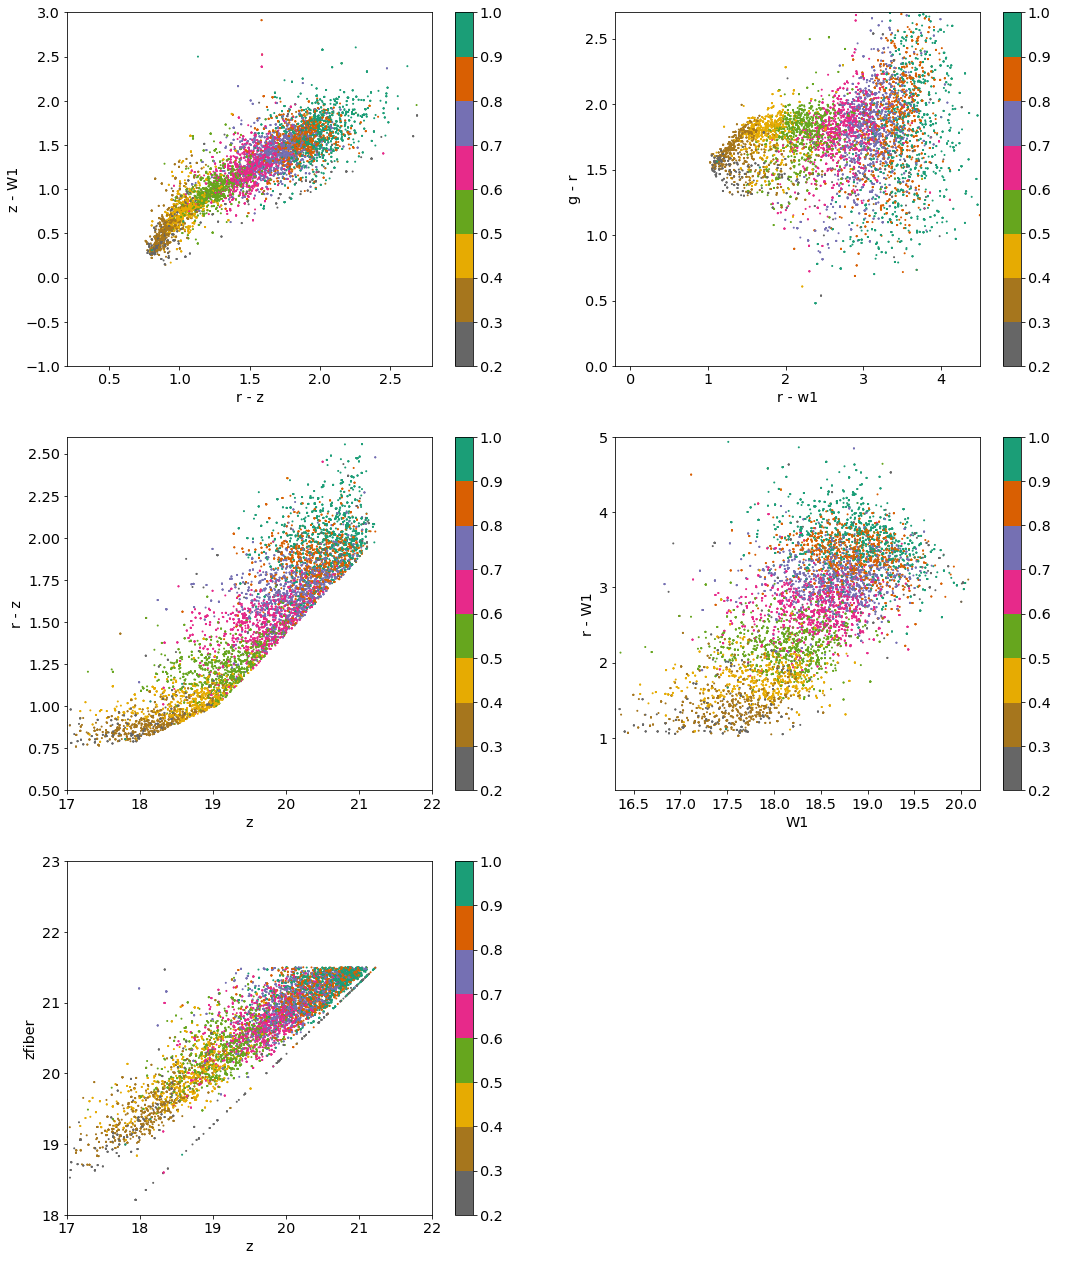

LRG_OPT failures:


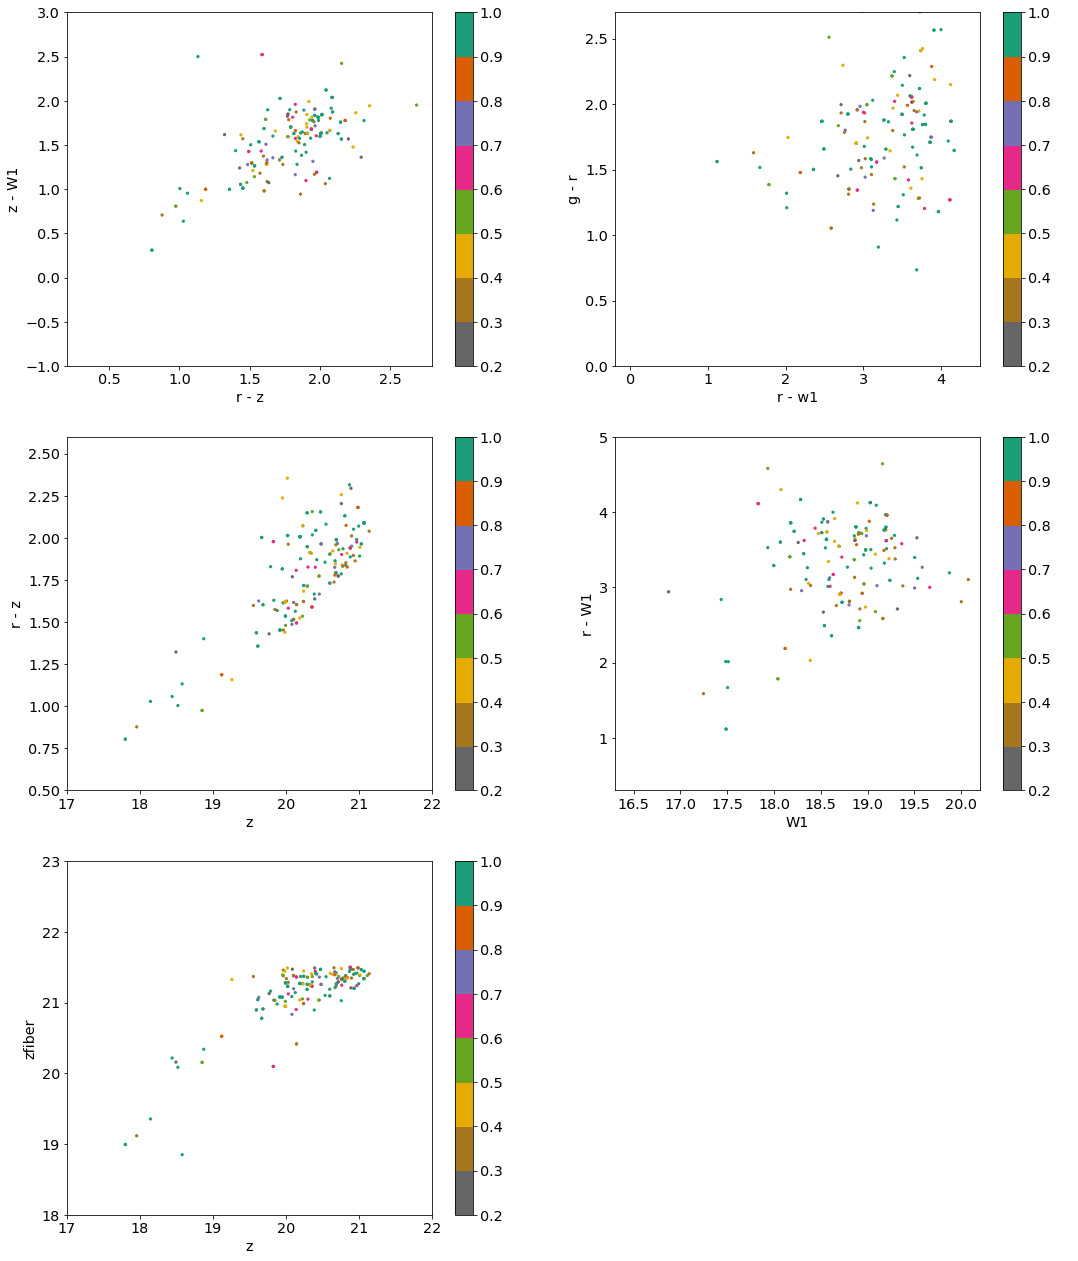

In [41]:
print('LRG_OPT successes:')
color_plot_3x2_simple(zbest[lrg_opt & mask_zwarn], color_col='Z', ms=1)
print('LRG_OPT failures:')
color_plot_3x2_simple(zbest[lrg_opt & mask_fail], color_col='Z', ms=5)

LRG_IR successes:


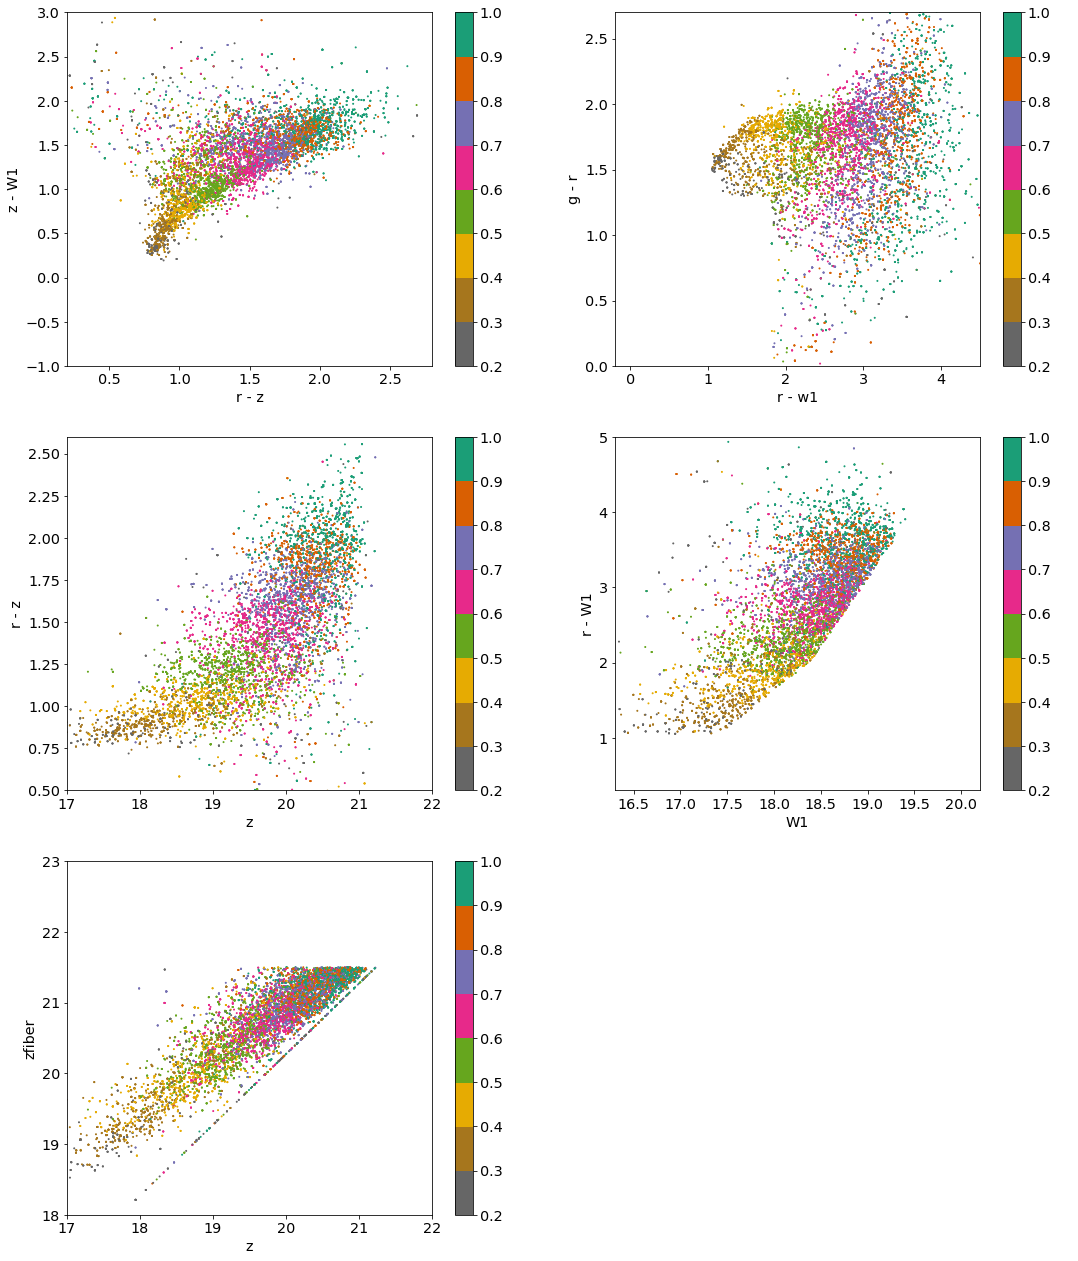

LRG_IR failures:


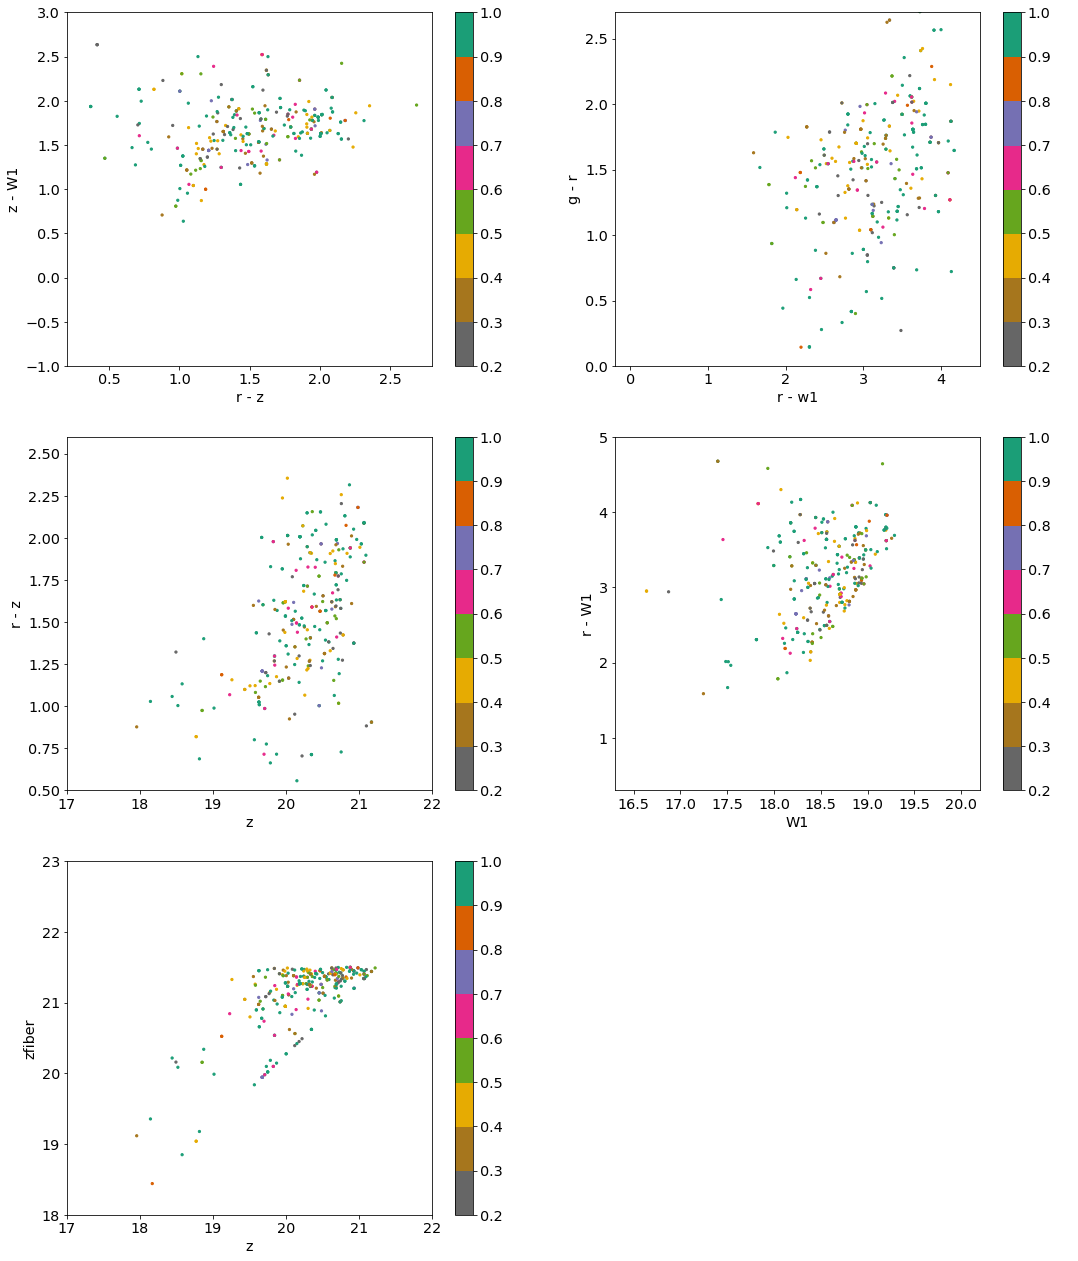

In [42]:
print('LRG_IR successes:')
color_plot_3x2_simple(zbest[lrg_ir & mask_zwarn], color_col='Z', ms=1)
print('LRG_IR failures:')
color_plot_3x2_simple(zbest[lrg_ir & mask_fail], color_col='Z', ms=5)

LRG_SV successes:


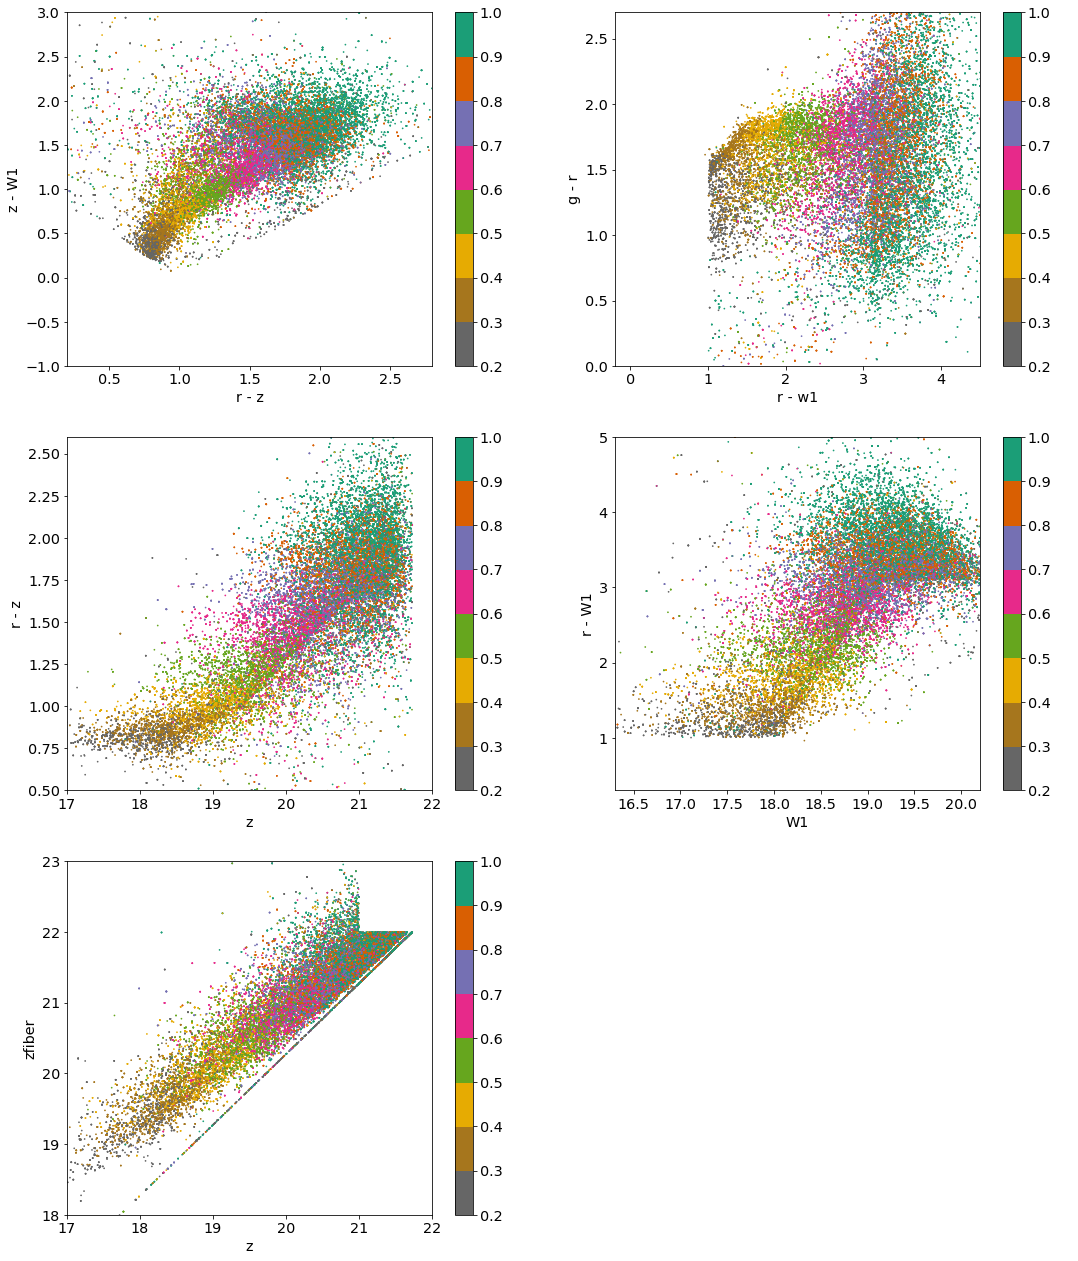

LRG_SV failures:


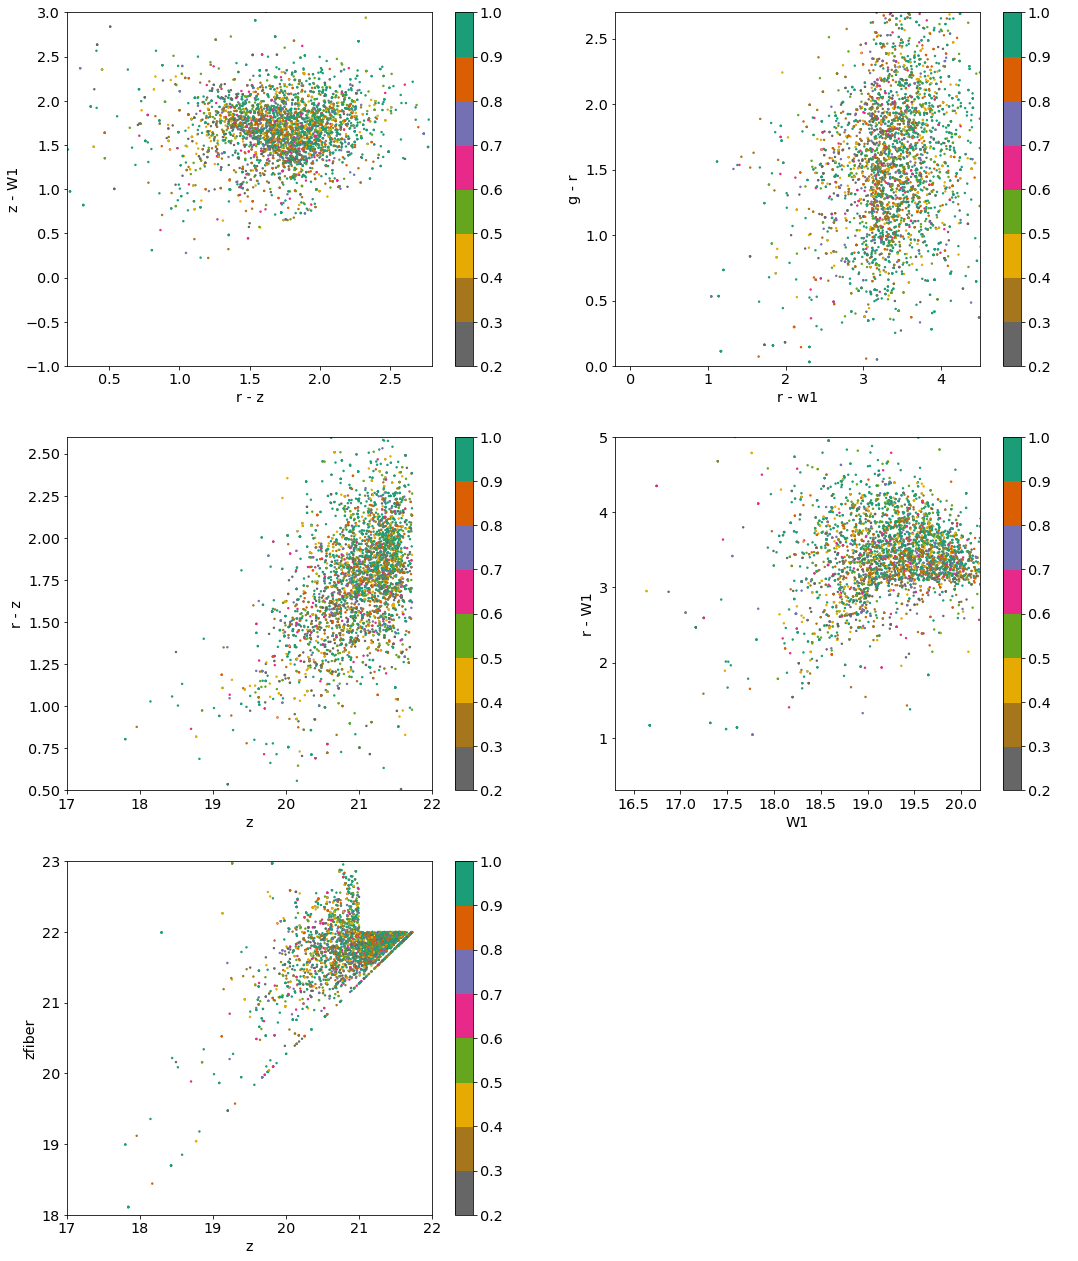

In [43]:
print('LRG_SV successes:')
color_plot_3x2_simple(zbest[lrg_sv & mask_zwarn], color_col='Z', ms=0.5)
print('LRG_SV failures:')
color_plot_3x2_simple(zbest[lrg_sv & mask_fail], color_col='Z', ms=2)